# Porównanie modeli predykcyjnych — podsumowanie końcowe

Niniejszy notatnik stanowi końcowy etap analizy modeli predykcyjnych
zbudowanych na danych lig piłkarskich. Jego celem jest porównanie
skuteczności różnych algorytmów uczenia maszynowego w zadaniu
klasyfikacji wyników meczów.

Analiza obejmuje zarówno pojedyncze ligi, jak i porównania
między ligami. W każdym zestawieniu uwzględnione są dwa warianty
regresji liniowej (Linear Regression vA oraz Linear Regression vB),
które pełnią rolę modeli bazowych (baseline) dla bardziej złożonych
algorytmów nieliniowych.

Ocena jakości modeli prowadzona jest z wykorzystaniem metryk:
- Accuracy — ogólna trafność klasyfikacji,
- Macro-F1 — miara równoważąca skuteczność predykcji pomiędzy klasami.

Notatnik ma charakter porównawczy i podsumowujący, a jego celem jest
identyfikacja modeli o najlepszych właściwościach predykcyjnych
oraz analiza różnic pomiędzy zastosowanymi podejściami.


In [23]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


In [24]:
LEAGUES = [
    "premier_league",
    "serie_a",
    "la_liga",
    "bundesliga",
    "ligue_1"
]

LEAGUES_DICT = {
    "premier_league": "Premier League",
    "serie_a": "Serie A",
    "la_liga": "La Liga",
    "bundesliga": "Bundesliga",
    "ligue_1": "Ligue 1",
    "all_leagues": "All Leagues"
}

LEAGUE = 0  # indeks aktualnie analizowanej ligi
RESULTS_ROOT = Path("../results")
SAVE_DIR = Path("../comparing")
SAVE_DIR.mkdir(exist_ok=True)
SPLIT_DATE = "2022-07-01"
N_TRAIN = 2660
N_TEST = 760

In [25]:
ALL_MODELS = [
    ("linear_regression", "Linear Regression OR", "linear_regression_opcja_A.csv"),
    ("linear_regression", "Linear Regression GF", "linear_regression_opcja_B.csv"),
    ("logistic_regression", "Logistic Regression", "logistic_regression_results.csv"),
    ("decision_tree", "Decision Tree", "decision_tree_results.csv"),
    ("random_forest", "Random Forest", "random_forest_results.csv"),
    ("xgboost", "XGBoost", "xgboost_results.csv"),
]


### Budowa zbioru wyników modeli

Funkcja agreguje wyniki wszystkich modeli i lig do jednej,
spójnej struktury danych wykorzystywanej w dalszej analizie.

In [26]:
def build_models_leagues_df(leagues):
    rows = []

    for league in leagues:
        for model_dir, model_name, filename in ALL_MODELS:
            path = RESULTS_ROOT / league / model_dir / filename
            if path.exists():
                r = pd.read_csv(path).iloc[0]

                rows.append({
                    "Model": model_name,
                    "League": LEAGUES_DICT[league],
                    "Accuracy": r["Accuracy"],
                    "Macro-F1": r["Macro-F1"],
                    "N_train": N_TRAIN,
                    "N_test": N_TEST,
                    "SplitDate": SPLIT_DATE,
                })

    return pd.DataFrame(rows)


### Wyniki modeli dla wybranej ligi

Tabela przedstawia wartości metryk Accuracy oraz Macro-F1
dla wszystkich modeli w obrębie jednej ligi.

In [27]:
df_all = build_models_leagues_df(LEAGUES)

current_league_name = LEAGUES_DICT[LEAGUES[LEAGUE]]
df_results = df_all[df_all["League"] == current_league_name].drop(columns="League")
df_results


,Model,Accuracy,Macro-F1,N_train,N_test,SplitDate
0,Linear Regression OR,0.393421,0.386763,2660,760,2022-07-01
1,Linear Regression GF,0.505263,0.484981,2660,760,2022-07-01
2,Logistic Regression,0.526316,0.495178,2660,760,2022-07-01
3,Decision Tree,0.518421,0.495760,2660,760,2022-07-01
4,Random Forest,0.535526,0.488486,2660,760,2022-07-01
5,XGBoost,0.542105,0.483144,2660,760,2022-07-01


# BARPLOT: ACCURACY vs MACRO-F1 (1 LIGA)

Wykres słupkowy przedstawia jednoczesne porównanie obu metryk
dla wszystkich analizowanych modeli w wybranej lidze.

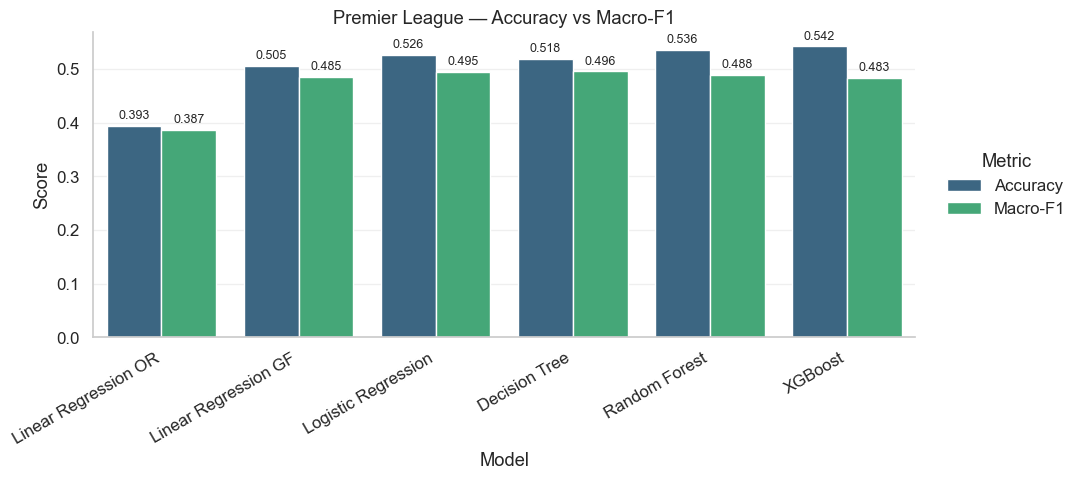

In [28]:
df_melted = df_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro-F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=df_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)

# wartości nad słupkami
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=9,
        padding=3
    )

plt.xticks(rotation=30, ha="right")
plt.ylabel("Score")
plt.title(f"{current_league_name} — Accuracy vs Macro-F1")

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
sns.set_theme(
    style="whitegrid",
    font_scale=1.05,
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        "grid.color": "#e5e5e5",
        "grid.linewidth": 0.8,
    }
)

# RANKING MODELI (MACRO-F1)

Modele uszeregowane malejąco według wartości Macro-F1,
co pozwala ocenić ich ogólną skuteczność klasyfikacyjną.

C:\Users\tdroz\AppData\Local\Temp\ipykernel_15272\2503055420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


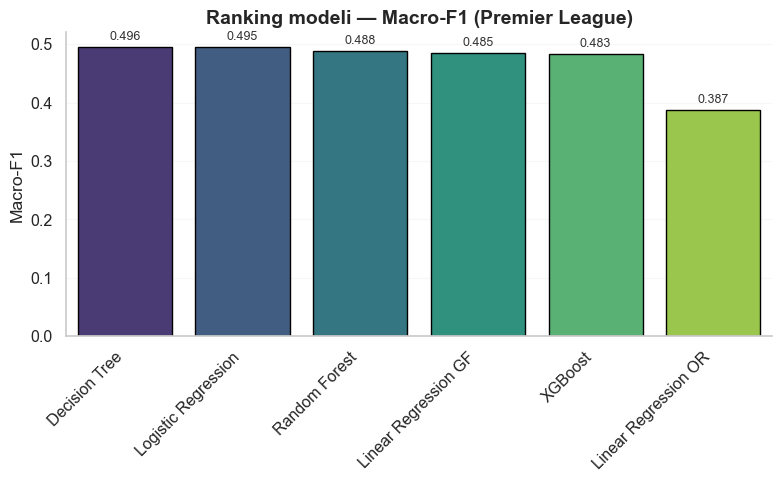

In [30]:
df_results_sorted_f1 = df_results.sort_values("Macro-F1", ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_results_sorted_f1,
    x="Model",
    y="Macro-F1",
    palette="viridis",
    edgecolor="black"
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=9,
        padding=3,
        color="#333333"
    )

plt.xticks(rotation=45, ha="right")
plt.title(f"Ranking modeli — Macro-F1 ({current_league_name})", fontsize=14, weight="bold")
plt.ylabel("Macro-F1")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# RANKING MODELI (ACCURACY)

Modele uszeregowane malejąco według wartości Accuracy.

C:\Users\tdroz\AppData\Local\Temp\ipykernel_15272\3235161747.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


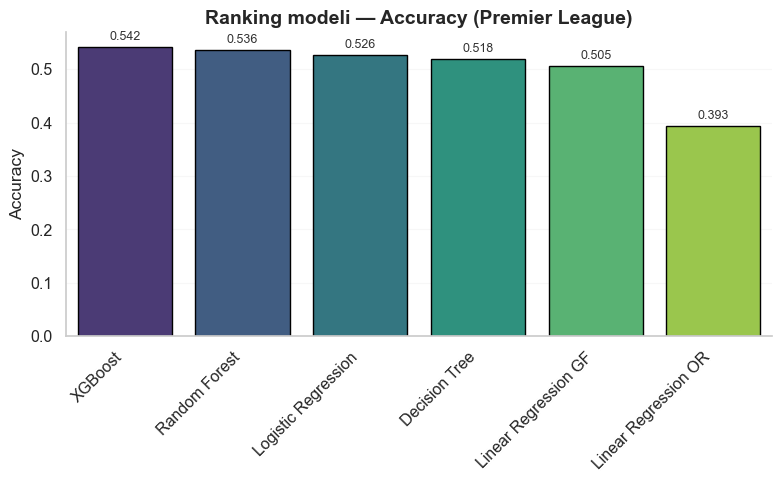

In [31]:
df_results_sorted_acc = df_results.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_results_sorted_acc,
    x="Model",
    y="Accuracy",
    palette="viridis",
    edgecolor="black"
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=9,
        padding=3,
        color="#333333"
    )

plt.xticks(rotation=45, ha="right")
plt.title(f"Ranking modeli — Accuracy ({current_league_name})", fontsize=14, weight="bold")
plt.ylabel("Accuracy")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# SCATTER: ACCURACY vs MACRO-F1

Wykres punktowy ilustruje zależność pomiędzy dwiema metrykami
dla poszczególnych modeli, umożliwiając ocenę kompromisu
między trafnością ogólną a zrównoważeniem predykcji.

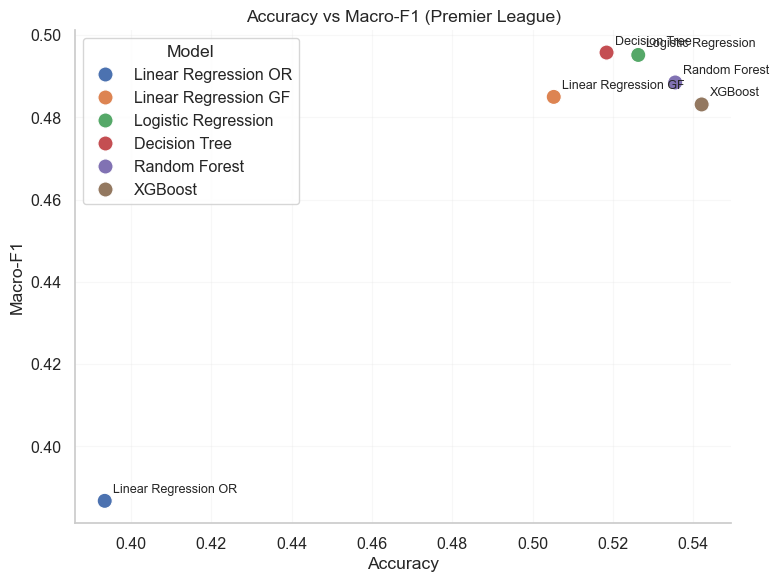

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_results,
    x="Accuracy",
    y="Macro-F1",
    hue="Model",
    s=120
)

for _, row in df_results.iterrows():
    plt.text(
        row["Accuracy"] + 0.002,
        row["Macro-F1"] + 0.002,
        row["Model"],
        fontsize=9
    )

plt.title(f"Accuracy vs Macro-F1 ({current_league_name})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# MULTI-LEAGUE: ACCURACY (SCATTER)


Wykres punktowy przedstawia skuteczność modeli w różnych ligach.
Kolor oznacza ligę, natomiast kształt markera identyfikuje model.

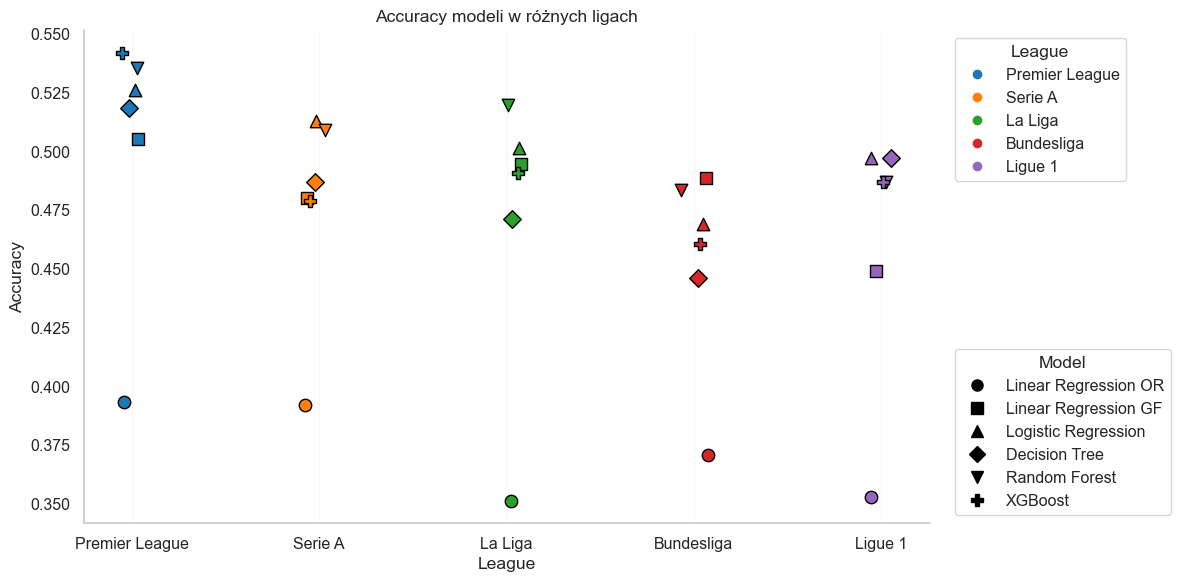

In [33]:
df_models_leagues = build_models_leagues_df(LEAGUES)
plt.figure(figsize=(12, 6))

leagues = df_models_leagues["League"].unique()
models = df_models_leagues["Model"].unique()

colors = plt.cm.tab10.colors
league_color_map = {l: colors[i % len(colors)] for i, l in enumerate(leagues)}

markers = ['o', 's', '^', 'D', 'v', 'P', 'X']
model_marker_map = {m: markers[i % len(markers)] for i, m in enumerate(models)}

x_positions = {l: i for i, l in enumerate(leagues)}
jitter = 0.08

for _, row in df_models_leagues.iterrows():
    x = x_positions[row["League"]] + np.random.uniform(-jitter, jitter)
    plt.scatter(
        x,
        row["Accuracy"],
        color=league_color_map[row["League"]],
        marker=model_marker_map[row["Model"]],
        s=80,
        edgecolor="black"
    )

plt.xticks(range(len(leagues)), leagues)
plt.ylabel("Accuracy")
plt.xlabel("League")
plt.title("Accuracy modeli w różnych ligach")
plt.grid(axis="y")
league_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=league_color_map[l],
           label=l, markersize=8)
    for l in leagues
]

model_handles = [
    Line2D([0], [0], marker=model_marker_map[m], color='black',
           linestyle='', label=m, markersize=8)
    for m in models
]

legend1 = plt.legend(
    handles=league_handles,
    title="League",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.gca().add_artist(legend1)

plt.legend(
    handles=model_handles,
    title="Model",
    loc="lower left",
    bbox_to_anchor=(1.02, 0)
)

plt.tight_layout()
plt.show()


### Porównanie lig w zależności od modelu

Poniższe wykresy przedstawiają porównanie skuteczności modeli
pomiędzy różnymi ligami. Każdy wykres odpowiada jednemu modelowi
i pokazuje wartości metryk Accuracy oraz Macro-F1 dla wszystkich lig.

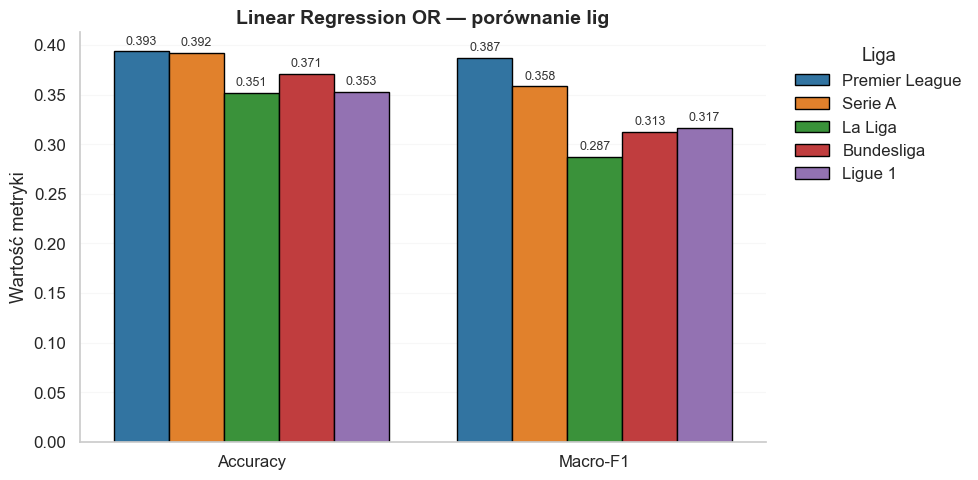

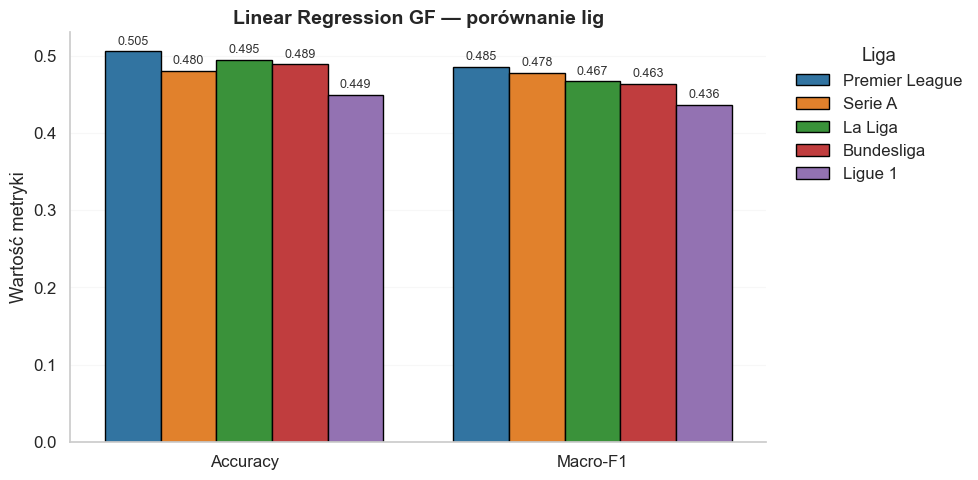

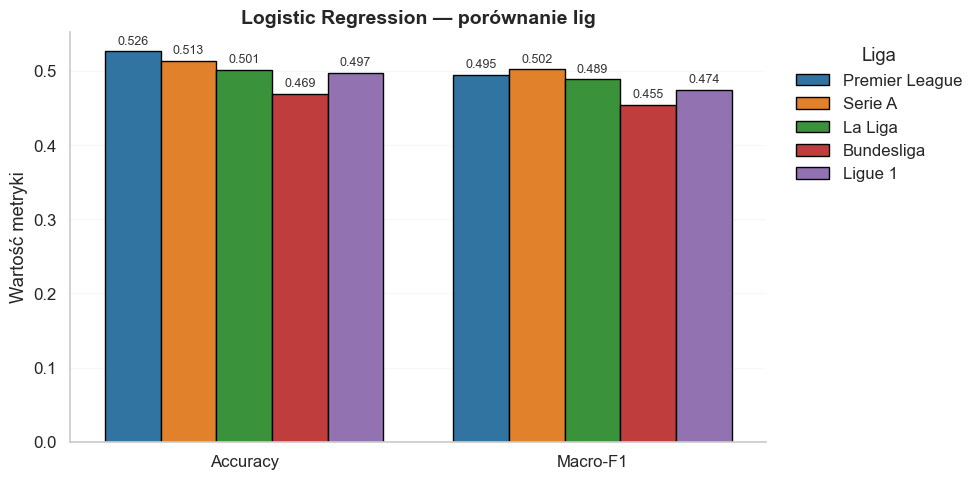

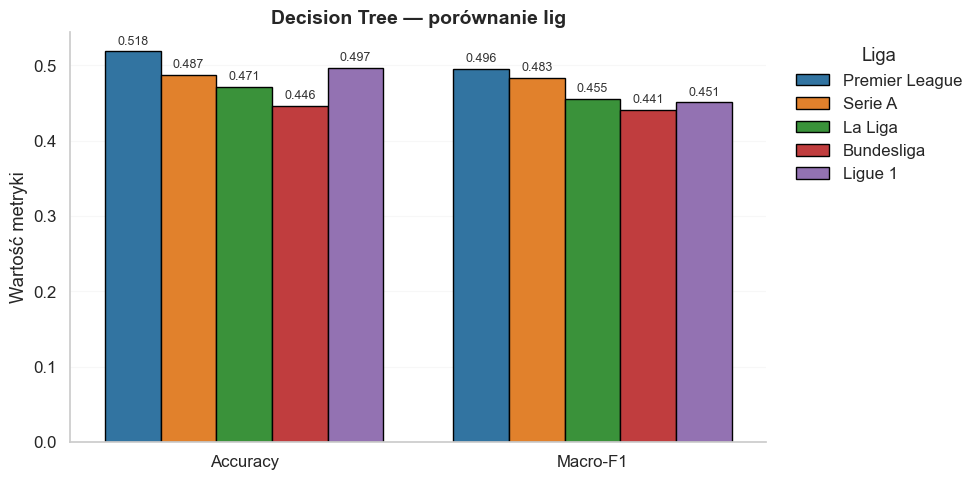

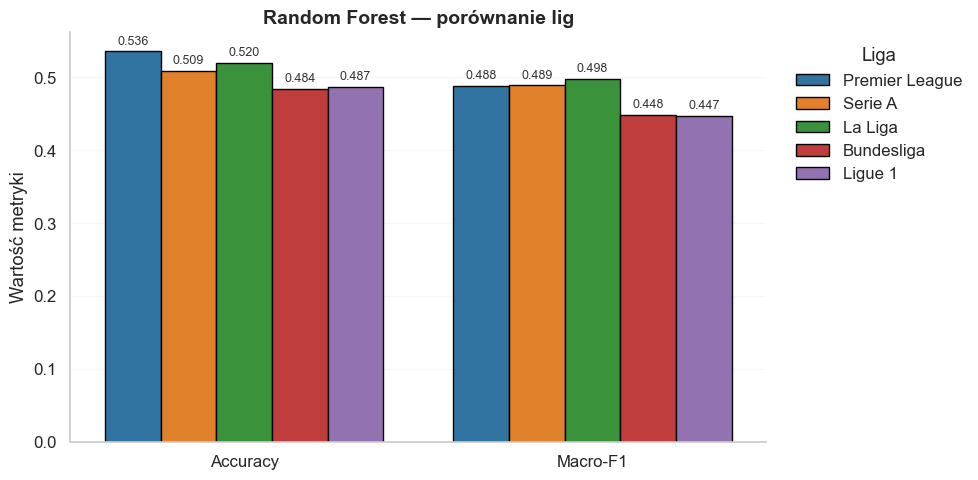

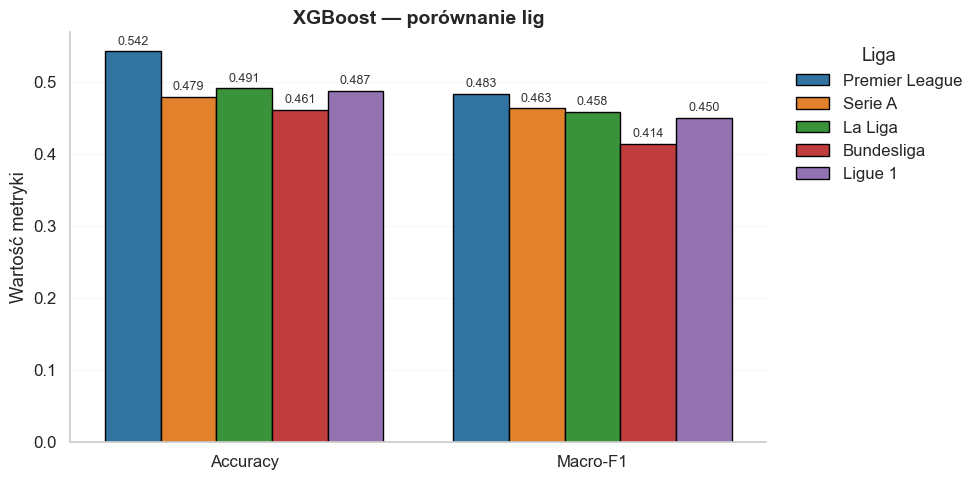

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        "grid.color": "#e5e5e5",
        "grid.linewidth": 0.8,
    }
)

for model_name in df_all["Model"].unique():

    df_model = df_all[df_all["Model"] == model_name]

    df_melted = df_model.melt(
        id_vars="League",
        value_vars=["Accuracy", "Macro-F1"],
        var_name="Metric",
        value_name="Score"
    )

    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data=df_melted,
        x="Metric",
        y="Score",
        hue="League",
        palette="tab10",        
        edgecolor="black"
    )

 
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            fontsize=9,
            padding=3,
            color="#333333"
        )

    ax.set_title(
        f"{model_name} — porównanie lig",
        fontsize=14,
        weight="bold"
    )
    ax.set_ylabel("Wartość metryki")
    ax.set_xlabel("")

    ax.legend(
        title="Liga",
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


### Ranking najlepszych wyników (model × liga)

Tabela przedstawia najlepsze konfiguracje model–liga
uszeregowane według wartości Accuracy. Każdy wiersz
odpowiada jednemu modelowi trenowanemu na konkretnej lidze.


In [35]:
df_ranking = df_all.sort_values(
    by="Accuracy",
    ascending=False
)

display(df_ranking.head(20))
df_ranking.to_csv(
    SAVE_DIR / "top20_model_league_accuracy.csv",
    index=False
)

,Model,League,Accuracy,Macro-F1,N_train,N_test,SplitDate
5,XGBoost,Premier League,0.542105,0.483144,2660,760,2022-07-01
4,Random Forest,Premier League,0.535526,0.488486,2660,760,2022-07-01
2,Logistic Regression,Premier League,0.526316,0.495178,2660,760,2022-07-01
16,Random Forest,La Liga,0.519737,0.498149,2660,760,2022-07-01
3,Decision Tree,Premier League,0.518421,0.495760,2660,760,2022-07-01
8,Logistic Regression,Serie A,0.513158,0.502004,2660,760,2022-07-01
10,Random Forest,Serie A,0.509211,0.488973,2660,760,2022-07-01
1,Linear Regression GF,Premier League,0.505263,0.484981,2660,760,2022-07-01
14,Logistic Regression,La Liga,0.501316,0.488505,2660,760,2022-07-01
26,Logistic Regression,Ligue 1,0.497085,0.474135,2660,760,2022-07-01


### Najlepszy model w każdej lidze (Macro-F1)

Tabela przedstawia najlepszy model dla każdej ligi
na podstawie wartości metryki Macro-F1.


In [36]:
top_model_per_league = (
    df_all
    .sort_values("Accuracy", ascending=False)
    .groupby("League", as_index=False)
    .first()
    .loc[:, ["League", "Model", "Macro-F1", "Accuracy"]]
)

top_model_per_league


,League,Model,Macro-F1,Accuracy
0,Bundesliga,Linear Regression GF,0.463006,0.488562
1,La Liga,Random Forest,0.498149,0.519737
2,Ligue 1,Logistic Regression,0.474135,0.497085
3,Premier League,XGBoost,0.483144,0.542105
4,Serie A,Logistic Regression,0.502004,0.513158


### Zysk względem modelu bazowego (Baseline HomeWin)

W tej sekcji przedstawiono porównanie skuteczności modeli
uczenia maszynowego względem prostego modelu bazowego
(HomeWin). Analizowany jest przyrost jakości predykcji
(Gain vs Baseline) dla metryk Accuracy oraz Macro-F1.


In [37]:
TARGET_LEAGUE = "premier_league"
TARGET_LEAGUE_NAME = LEAGUES_DICT[TARGET_LEAGUE]

BASELINE_FILES = {
    "Linear Regression": (
        "linear_regression",
        "baseline_vs_linear_regression.csv"
    ),
    "Logistic Regression": (
        "logistic_regression",
        "baseline_vs_logistic_regression_multiclass.csv"
    ),
    "Decision Tree": (
        "decision_tree",
        "baseline_vs_decision_tree.csv"
    ),
    "Random Forest": (
        "random_forest",
        "baseline_vs_random_forest.csv"
    ),
    "XGBoost": (
        "xgboost",
        "baseline_vs_xgboost.csv"
    ),
}
rows = []

for model_name, (model_dir, filename) in BASELINE_FILES.items():

    path = RESULTS_ROOT / TARGET_LEAGUE / model_dir / filename

    if not path.exists():
        print(f"Brak pliku: {path}")
        continue

    df = pd.read_csv(path)

    for _, row in df.iterrows():
        rows.append({
            "League": TARGET_LEAGUE_NAME,
            "Model": model_name,
            "Metric": row["Metric"],
            "Gain_vs_Baseline": row["Gain_vs_Baseline"]
        })

df_baseline_gain = pd.DataFrame(rows)

df_baseline_gain_pp = df_baseline_gain.copy()
df_baseline_gain_pp["Gain_pp"] = df_baseline_gain_pp["Gain_vs_Baseline"] * 100


C:\Users\tdroz\AppData\Local\Temp\ipykernel_15272\2814075118.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


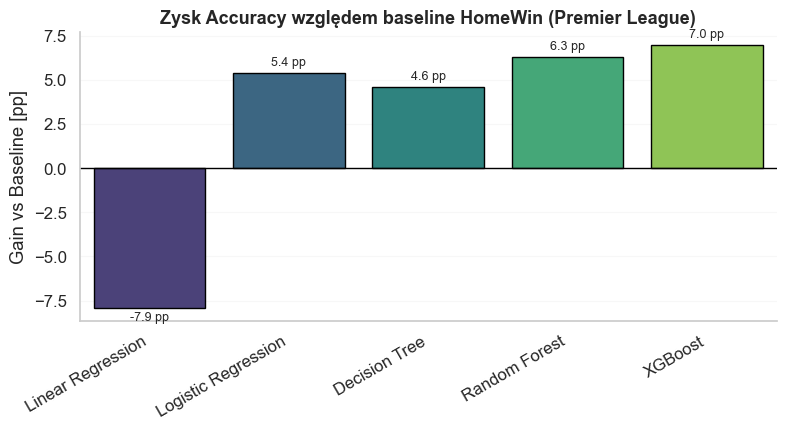

C:\Users\tdroz\AppData\Local\Temp\ipykernel_15272\2814075118.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


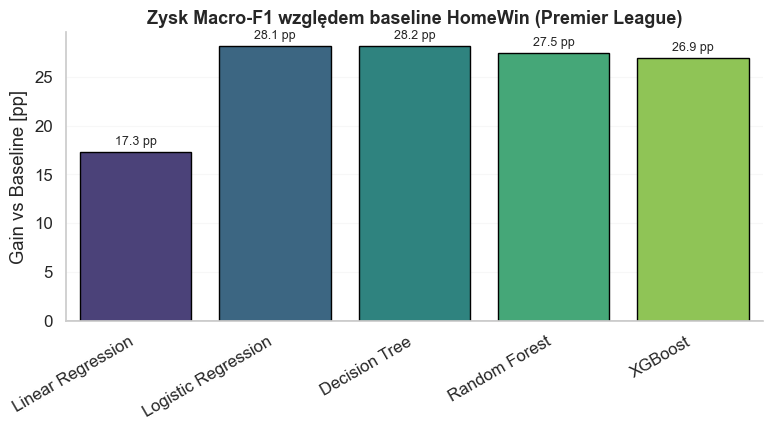

In [38]:
df_acc = df_baseline_gain_pp[df_baseline_gain_pp["Metric"] == "Accuracy"]

plt.figure(figsize=(8, 4.5))

ax = sns.barplot(
    data=df_acc,
    x="Model",
    y="Gain_pp",
    palette="viridis",
    edgecolor="black"
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f pp",
        fontsize=9,
        padding=3
    )

plt.axhline(0, color="black", linewidth=1)
plt.title(
    "Zysk Accuracy względem baseline HomeWin (Premier League)",
    fontsize=13,
    weight="bold"
)
plt.ylabel("Gain vs Baseline [pp]")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

df_f1 = df_baseline_gain_pp[df_baseline_gain_pp["Metric"] == "Macro-F1"]

plt.figure(figsize=(8, 4.5))

ax = sns.barplot(
    data=df_f1,
    x="Model",
    y="Gain_pp",
    palette="viridis",
    edgecolor="black"
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f pp",
        fontsize=9,
        padding=3
    )

plt.axhline(0, color="black", linewidth=1)
plt.title(
    "Zysk Macro-F1 względem baseline HomeWin (Premier League)",
    fontsize=13,
    weight="bold"
)
plt.ylabel("Gain vs Baseline [pp]")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Stabilność modeli predykcyjnych w czasie — Premier League

Poniższy wykres przedstawia zmianę wartości metryki Accuracy w kolejnych
okresach czasowych dla wybranych modeli predykcyjnych trenowanych
na danych Premier League. Analiza ma charakter porównawczy i ilustracyjny,
a jej celem jest ocena stabilności modeli w czasie, rozumianej jako
odporność na wahania jakości predykcji w kolejnych miesiącach.


In [39]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_ROOT = Path("../results")
LEAGUE = "premier_league"

FILES = {
    "Linear Regression OR": "linear_regression/accuracy_per_month_linear_A.csv",
    "Logistic Regression": "logistic_regression/accuracy_per_month_logistic.csv",
    "Decision Tree": "decision_tree/accuracy_per_month_decision_tree.csv",
    "Random Forest": "random_forest/accuracy_per_month_random_forest.csv",
    "XGBoost": "xgboost/accuracy_per_month_xgboost.csv",
}

dfs = []

for model_name, rel_path in FILES.items():
    path = RESULTS_ROOT / LEAGUE / rel_path
    if not path.exists():
        print(f"Brak pliku: {path}")
        continue

    df = pd.read_csv(path)
    df["Model"] = model_name
    dfs.append(df)

df_time = pd.concat(dfs, ignore_index=True)
df_time["YearMonth"] = pd.to_datetime(df_time["YearMonth"])

df_time


,YearMonth,Accuracy,Model
0,2022-08-01,0.530612,Linear Regression OR
1,2022-09-01,0.166667,Linear Regression OR
2,2022-10-01,0.338983,Linear Regression OR
3,2022-11-01,0.200000,Linear Regression OR
4,2022-12-01,0.388889,Linear Regression OR
...,...,...,...
95,2024-01-01,0.750000,XGBoost
96,2024-02-01,0.547619,XGBoost
97,2024-03-01,0.514286,XGBoost
98,2024-04-01,0.528302,XGBoost


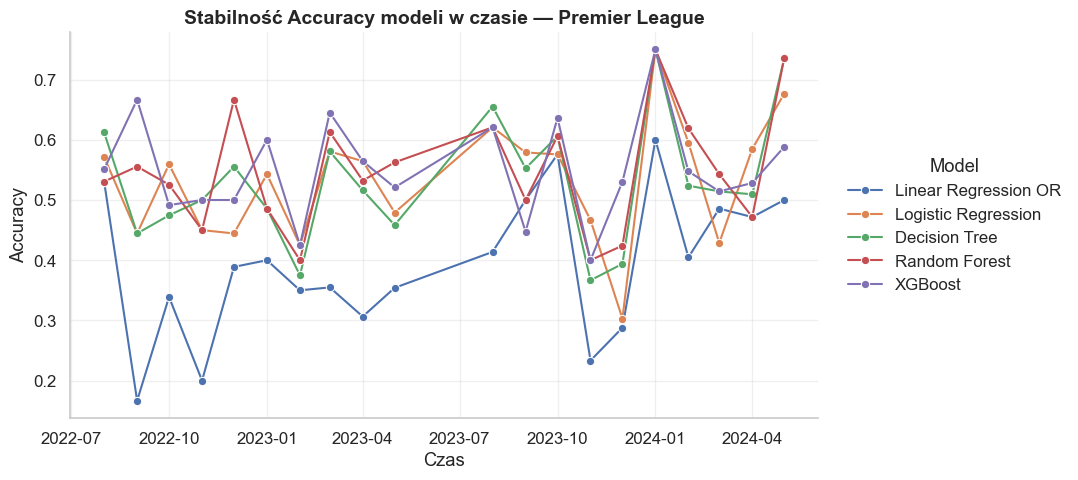

In [40]:
sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        "grid.alpha": 0.3,
    }
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=df_time,
    x="YearMonth",
    y="Accuracy",
    hue="Model",
    marker="o"
)

plt.title("Stabilność Accuracy modeli w czasie — Premier League", fontsize=14, weight="bold")
plt.ylabel("Accuracy")
plt.xlabel("Czas")
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False
)
plt.tight_layout()
plt.show()


Wykres przedstawia zmianę wartości Accuracy w czasie dla wybranych modeli
predykcyjnych trenowanych na danych Premier League. Widoczna jest większa
stabilność modeli zespołowych (Random Forest, XGBoost) w porównaniu do
prostszych algorytmów, takich jak regresja liniowa czy logistyczna.
Jednoczesne spadki jakości predykcji obserwowane dla wszystkich modeli
sugerują występowanie okresowych zmian w charakterystyce danych,
niezależnych od zastosowanego algorytmu.

### Dominacja modeli w czasie (najlepsza Accuracy w danym miesiącu)

Poniższy wykres przedstawia, który model osiągał najwyższą wartość
Accuracy w poszczególnych okresach czasowych. Wizualizacja pozwala
ocenić, czy przewaga danego modelu ma charakter trwały, czy też
zmienia się w czasie.


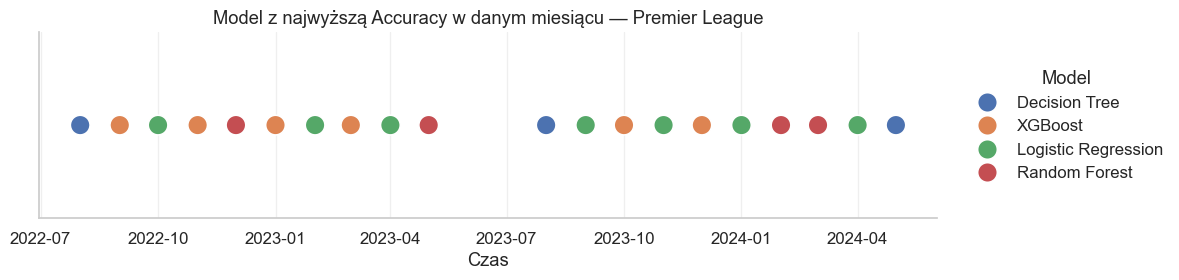

In [41]:
# wybór najlepszego modelu w każdym miesiącu
best_per_month = (
    df_time
    .sort_values("Accuracy", ascending=False)
    .groupby("YearMonth")
    .first()
    .reset_index()
)

plt.figure(figsize=(12, 3))

sns.scatterplot(
    data=best_per_month,
    x="YearMonth",
    y=[1] * len(best_per_month),
    hue="Model",
    s=200
)

plt.yticks([])
plt.xlabel("Czas")
plt.title("Model z najwyższą Accuracy w danym miesiącu — Premier League")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False
)

plt.tight_layout()
plt.show()


### Podsumowanie porównań modeli („winnerzy”)

Poniższa tabela syntetycznie podsumowuje wyniki przeprowadzonych
porównań modeli predykcyjnych. Dla każdego kryterium wskazano model,
który osiągnął najlepszy rezultat lub wykazywał najbardziej pożądane
właściwości w kontekście analizy danych Premier League.


In [42]:

# FILTR MODELI 

valid_models = [
    "Linear Regression OR",
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

df_results_filtered = df_results[
    df_results["Model"].isin(valid_models)
].copy()


# Najwyższa Accuracy
best_accuracy_model = (
    df_results_filtered
    .sort_values("Accuracy", ascending=False)
    .iloc[0]["Model"]
)


#  Najwyższa Macro-F1
best_macro_f1_model = (
    df_results_filtered
    .sort_values("Macro-F1", ascending=False)
    .iloc[0]["Model"]
)


# Największy zysk vs baseline (Accuracy)
best_gain_acc = (
    df_baseline_gain_pp
    .query("Metric == 'Accuracy'")
    .sort_values("Gain_pp", ascending=False)
    .iloc[0]["Model"]
)


#  Największy zysk vs baseline (Macro-F1)
best_gain_f1 = (
    df_baseline_gain_pp
    .query("Metric == 'Macro-F1'")
    .sort_values("Gain_pp", ascending=False)
    .iloc[0]["Model"]
)


# Największa stabilność w czasie
stability_df = (
    df_time
    .groupby("Model", as_index=False)
    .agg(Std_Accuracy=("Accuracy", "std"))
)

most_stable_model = (
    stability_df
    .sort_values("Std_Accuracy")
    .iloc[0]["Model"]
)


#  Najlepszy kompromis jakość / złożoność
simple_models = ["Linear Regression OR", "Logistic Regression"]

best_simple_model = (
    df_results_filtered[
        df_results_filtered["Model"].isin(simple_models)
    ]
    .sort_values("Macro-F1", ascending=False)
    .iloc[0]["Model"]
)


#  Największa interpretowalność (opisowo)
most_interpretable_model = "Logistic Regression"


# FINALNA TABELA „WINNERÓW”
winners_summary = pd.DataFrame({
    "Kryterium": [
        "Najwyższa Accuracy",
        "Najwyższa Macro-F1",
        "Największy zysk vs baseline (Accuracy)",
        "Największy zysk vs baseline (Macro-F1)",
        "Największa stabilność w czasie (min std)",
        "Najlepszy kompromis jakość / złożoność",
        "Największa interpretowalność (opisowo)"
    ],
    "Model (Premier League)": [
        best_accuracy_model,
        best_macro_f1_model,
        best_gain_acc,
        best_gain_f1,
        most_stable_model,
        best_simple_model,
        most_interpretable_model
    ]
})

winners_summary


,Kryterium,Model (Premier League)
0,Najwyższa Accuracy,XGBoost
1,Najwyższa Macro-F1,Decision Tree
2,Największy zysk vs baseline (Accuracy),XGBoost
3,Największy zysk vs baseline (Macro-F1),Decision Tree
4,Największa stabilność w czasie (min std),XGBoost
5,Najlepszy kompromis jakość / złożoność,Logistic Regression
6,Największa interpretowalność (opisowo),Logistic Regression


### Porównanie modeli i lig — heatmapa Macro-F1

Poniższa heatmapa przedstawia wartości metryki Macro-F1 dla kombinacji
model–liga. Wizualizacja umożliwia jednoczesną ocenę jakości modeli
w poszczególnych ligach oraz ich stabilności między ligami, stanowiąc
syntetyczne podsumowanie całej analizy porównawczej.


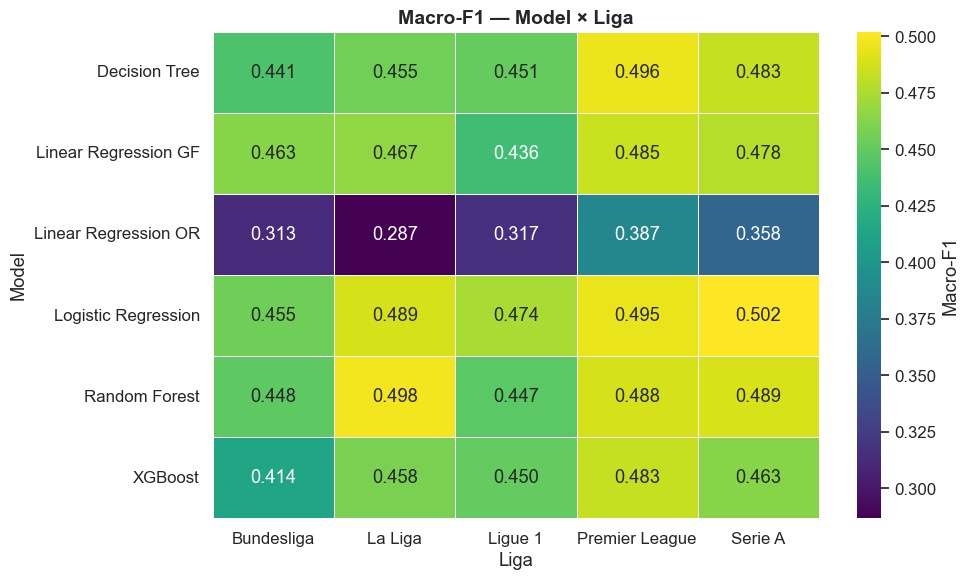

In [43]:

pivot_f1 = df_models_leagues.pivot(
    index="Model",
    columns="League",
    values="Macro-F1"
)
order = pivot_f1.mean(axis=1).sort_values(ascending=False).index
pivot_acc = pivot_f1.loc[order]

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_f1,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Macro-F1"}
)

plt.title("Macro-F1 — Model × Liga", fontsize=14, weight="bold")
plt.xlabel("Liga")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


### Porównanie modeli i lig — heatmapa Accuracy

Poniższa heatmapa przedstawia wartości metryki Accuracy dla kombinacji
model–liga. W zestawieniu z heatmapą Macro-F1 umożliwia ona ocenę,
czy wysokie wartości skuteczności ogólnej idą w parze z jakością
predykcji we wszystkich klasach.


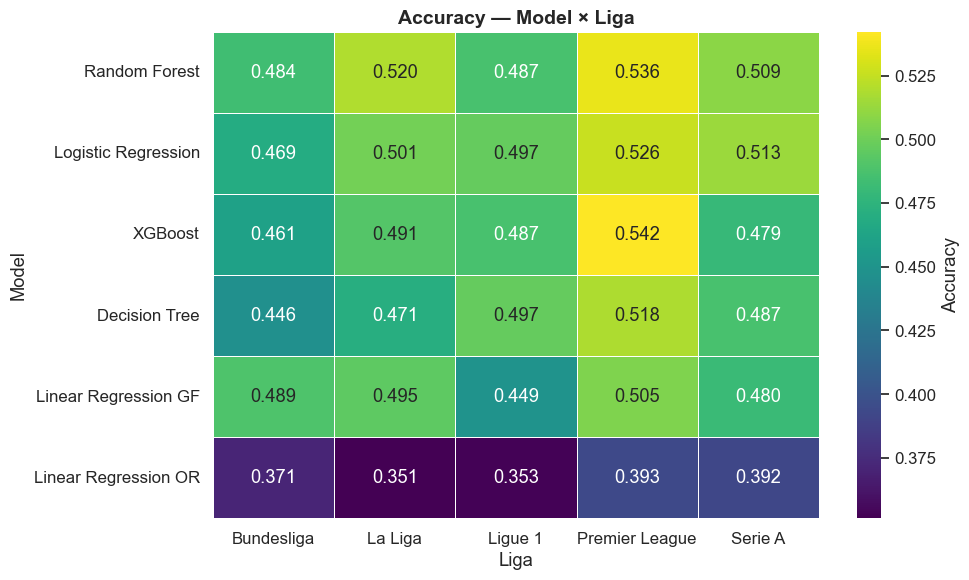

In [44]:

pivot_acc = df_models_leagues.pivot(
    index="Model",
    columns="League",
    values="Accuracy"
)
order = pivot_acc.mean(axis=1).sort_values(ascending=False).index
pivot_acc = pivot_acc.loc[order]

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_acc,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Accuracy"}
)

plt.title("Accuracy — Model × Liga", fontsize=14, weight="bold")
plt.xlabel("Liga")
plt.ylabel("Model")
plt.tight_layout()
plt.show()
